# Data Cleaning using Python : E - Commerce Data Leak Solution 

### 1. IMPORT LIBRARIES 

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

### 2. LOADING THE DATAFRAMES 

In [5]:
orders_df = pd.read_csv('orders.csv')
order_payments_df = pd.read_csv('order_payments.csv')
customers_df = pd.read_csv('customers.csv')
order_items_df = pd.read_csv('order_items.csv')
products_df = pd.read_csv('products.csv')
pcnt_df = pd.read_csv('product_category_name_translation.csv')
sellers_df = pd.read_csv('sellers.csv')
order_reviews_df = pd.read_csv('order_reviews.csv')

### 3. DATASET OVERVIEW 

In [7]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [10]:
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [12]:
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [14]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [16]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [18]:
pcnt_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [20]:
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [22]:
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [24]:
orders_df.shape

(99441, 8)

#### Total records in each table : 

1. orders_df = (99,441 ,8)
2. order_payments_df = (1,03,886 , 5)
3. customers_df = (99,441 , 5)
4. order_items_df = (1,12,650 , 7)
5. products_df = (32,951 , 9)
6. pcnt_df = (71,2)
7. sellers_df = (3095 , 4)
8. order_reviews_df = (99,224 , 7)

### 4. CHECK FOR DUPLICATES AND NULLS 

In [28]:
# There are no duplicates in any of the tables 

In [30]:
orders_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [32]:
products_df.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [34]:
order_reviews_df.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

### 5. TREATMENT OF NULLS [orders_df , products_df , order_reviews_df]

In [37]:
#TREATMENT OF NULLS - products_df

In [39]:
pcnt_df.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [41]:
#treatment of nulls - product_category_name fill with unknown 

products_df['product_category_name'] = products_df['product_category_name'].fillna('outro') #outro is the portugese name for other 

#merge with the translation of the dataframe use a left join to not lose any of the products 
products_df = pd.merge(products_df, pcnt_df, on='product_category_name',how ='left')


In [43]:
products_df['product_category_name_english'] = products_df['product_category_name_english'].fillna('unknown_category')
products_df.drop(columns=['product_category_name'], inplace=True)
products_df.rename(columns = {'product_category_name_english': 'product_category'}, inplace=True)

In [45]:
products_df.isnull().sum()

product_id                      0
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
product_category                0
dtype: int64

In [47]:
cols_to_fix = ['product_weight_g' , 'product_length_cm','product_height_cm','product_width_cm']

for col in cols_to_fix:
    products_df[col] = products_df[col].fillna(products_df[col].median())
# fill the columns with median that is friendly towards outliers 

#now fill the remaining columns with 0 
metadata_cols = ['product_name_lenght','product_description_lenght','product_photos_qty']
products_df[metadata_cols] = products_df[metadata_cols].fillna(0)

In [49]:
products_df.isnull().sum()

product_id                    0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
product_category              0
dtype: int64

In [51]:
# TREATMENT OF NULLS - orders_df 

In [53]:
orders_df.dtypes
# first convert all the date columns to datetime first 

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [55]:
date_cols = ['order_purchase_timestamp' , 'order_approved_at' , 'order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date']

In [57]:
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

In [59]:
orders_df.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [61]:
orders_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [63]:
#The process gap analysis to full nulls in orders df for further simple analysis 

In [65]:
#define the logic for the gap type 
conditions = [
    (orders_df['order_approved_at'].isnull()) & (orders_df['order_status']=='delivered'), 
    (orders_df['order_approved_at'].isnull()) & (orders_df['order_status'] !='delivered'),
    (orders_df['order_delivered_customer_date'].isnull()) & (orders_df['order_status'] !='cancelled')
]

choices =[
    'Critical_Bypass', #delivered but never approved 
    'Approval Leak', #not approved but in another status 
    'In_Progress' #simply hasn't reached the customer yet 
]

orders_df['process_gap'] =np.select(conditions,choices,default='Standard_Process')

print("--- Process Gap Analysis---")
print(orders_df['process_gap'].value_counts())

--- Process Gap Analysis---
process_gap
Standard_Process    96462
In_Progress          2819
Approval Leak         146
Critical_Bypass        14
Name: count, dtype: int64


In [67]:
# the processgap is used to point out that there is an error so we do not remove the nulls from the orders dataframe purposely 

In [69]:
#TREATMENT OF NULLS - order_reviews_df 
order_reviews_df.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [71]:
order_reviews_df['review_comment_title'] = order_reviews_df['review_comment_title'].fillna('No Title')
order_reviews_df['review_comment_message'] = order_reviews_df['review_comment_message'].fillna('No Message')

#create a binary red flag : 1- if they wrote something , 0 if they were silent 
order_reviews_df['is_customer_silent'] =np.where(order_reviews_df['review_comment_message']=='No Message',1,0)
print ("Review text neutralized and silence flag created !")

Review text neutralized and silence flag created !


In [73]:
order_reviews_df.isnull().sum()

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
is_customer_silent         0
dtype: int64

In [75]:
# FINAL NULLS CHECK FOR ALL THE DATAFRAMES 

all_dfs = [orders_df , order_items_df,order_payments_df,order_reviews_df,products_df,customers_df,sellers_df,pcnt_df]
df_names = ['Orders','Items','Payments','Reviews','Products','Customers','Sellers','Translations']

for name , df in zip(df_names,all_dfs):
    print(f"---NULL COUNTS FOR :{name}---")
    print(df.isnull().sum())
    print("\n")

---NULL COUNTS FOR :Orders---
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
process_gap                         0
dtype: int64


---NULL COUNTS FOR :Items---
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


---NULL COUNTS FOR :Payments---
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


---NULL COUNTS FOR :Reviews---
review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answe

### 6. MASTER TABLE CONSOLIDATION AND FRAUD ATTRIBUTION 

In [78]:
# SENTIMENTAL MASTER TABLE BUILDING 

In [80]:
#1. Start with the Orders as the base 
master_df = pd.merge(orders_df,order_payments_df, on='order_id',how='left')

In [82]:
#2. Add the Items (This links the price)
master_df = pd.merge(master_df,order_items_df,on='order_id',how='left')

In [84]:
#3. Add the Products (This links Category and Dimensions )
#Note : We only take the columns we need to keep it fast 
master_df = pd.merge(master_df , products_df, on='product_id',how='left')

In [86]:
#4. Add the Reviews (This links the Sentiment/Silence)
master_df = pd.merge(master_df,order_reviews_df, on='order_id',how='left')

In [88]:
# Step 1 - Master table created (your existing code)
print (f"Project Sentinel : Master Table Created !")
print (f"Total Transactions to Analyze :{len(master_df)}")

# Step 2 - NEW: Aggregate correct order price BEFORE calculating leak
order_total_price = order_items_df.groupby('order_id')['price'].sum().reset_index()
order_total_price.rename(columns={'price': 'total_order_price'}, inplace=True)
master_df = pd.merge(master_df, order_total_price, on='order_id', how='left')

# Step 3 - NOW calculate revenue leak using correct total price
master_df['revenue_leak'] = master_df['total_order_price'] - master_df['payment_value']

Project Sentinel : Master Table Created !
Total Transactions to Analyze :119143


In [195]:
print(ghost_orders['process_gap'].value_counts())

process_gap
Standard_Process    593
In_Progress          17
Name: count, dtype: int64


In [90]:
master_df.columns 

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'process_gap', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'order_item_id', 'product_id',
       'seller_id', 'shipping_limit_date', 'price', 'freight_value',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'product_category',
       'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'is_customer_silent', 'total_order_price',
       'revenue_leak'],
      dtype='object')

#### THE SENTINEL COLUMN AUDIT 

1. process_gap + revenue_leak : this is the primary focus. it tells us why money is missing and how much is gone

2. payment_type + price : this helps us to see if certain payment methods (like vouchers or credit cards) are being abused to bypass the price.

3. is_customer_silent + review_score : this lets us see if the victims are complaining or if the ghost orders are just dissapearing into the void  

#### Financial Damage Report 

Group by product_category and look at the revenue leak 

In [94]:
# We want the HIGHEST POSITIVE values (where Price > Payment)
true_theft_categories = master_df.groupby('product_category')['revenue_leak'].sum().sort_values(ascending=False).head(10)

print("--- THE REAL REVENUE LEAK (MONEY GONE) ---")
print(true_theft_categories)

--- THE REAL REVENUE LEAK (MONEY GONE) ---
product_category
agro_industry_and_commerce    11977.92
computers                      9141.72
security_and_services           -41.22
fashion_childrens_clothes      -145.84
la_cuisine                     -217.56
cds_dvds_musicals              -289.43
arts_and_craftmanship          -420.49
music                          -488.76
books_imported                 -556.68
home_comfort_2                 -644.88
Name: revenue_leak, dtype: float64


In [96]:
#2. Display the top 10 categories with the most 'Missing Money'
print ("--- TOP 10 REVENUE LEAK CATEGORIES---")
print(category_analysis.head(10))

--- TOP 10 REVENUE LEAK CATEGORIES---


NameError: name 'category_analysis' is not defined

In [98]:
#filter only the rows where a leak actually exists (Price>Payment)
theft_only_df = master_df[master_df['revenue_leak']>0]

In [100]:
true_fraud_ranking = theft_only_df.groupby('product_category')['revenue_leak'].sum().sort_values(ascending=False).head(10)

In [102]:
print(true_fraud_ranking)

product_category
bed_bath_table           69965.35
health_beauty            47605.68
watches_gifts            46381.97
furniture_decor          41052.60
sports_leisure           37801.07
garden_tools             36575.32
housewares               35793.67
computers_accessories    31625.05
auto                     28912.95
cool_stuff               26495.66
Name: revenue_leak, dtype: float64


In [104]:
leak_by_gap = theft_only_df.groupby('process_gap')['revenue_leak'].sum().sort_values(ascending =False)
print ("--- WHERE IS THE MONEY GOING ? ---")
print(leak_by_gap) #to find how much of revenue leak is actually happening due to process gap [fishy order status]

--- WHERE IS THE MONEY GOING ? ---
process_gap
Standard_Process    651822.44
In_Progress          24047.42
Name: revenue_leak, dtype: float64


In [106]:
#lets find the average leak - a little bit money from everyone or a lot of money from a few people we need to find the average leak per order 

In [108]:
#Calculate the average leak for Standard Process vs others 
avg_leak = theft_only_df.groupby('process_gap')['revenue_leak'].mean()

print (" --- AVERAGE LEAK PER TRANSACTION ---")
print (avg_leak)

#lets count how many transactions are actually leaking 
leak_counts = theft_only_df['process_gap'].value_counts()
print ("\n-- NUMBER OF LEAKING TRANSACTIONS ---")
print (leak_counts)

 --- AVERAGE LEAK PER TRANSACTION ---
process_gap
In_Progress         162.482568
Standard_Process     94.590399
Name: revenue_leak, dtype: float64

-- NUMBER OF LEAKING TRANSACTIONS ---
process_gap
Standard_Process    6891
In_Progress          148
Name: count, dtype: int64


In [110]:
#WEIGHT OF LEAKING ITEMS VS NON LEAKING ITEMS 

leaking_weight = theft_only_df['product_weight_g'].mean()
all_items_weight = master_df['product_weight_g'].mean()

print (f"--- WEIGHT ANALYSIS--")
print (f"Average Weight of Leaking Items : {leaking_weight:.2f}g")
print (f"Average Weight of All Items : {all_items_weight: .2f}g")

--- WEIGHT ANALYSIS--
Average Weight of Leaking Items : 2566.84g
Average Weight of All Items :  2112.01g


In [179]:
#TOTAL BYPASSES 

ghost_orders = master_df[(master_df['payment_value']==0) | (master_df['payment_value']< (master_df['price'] *0.1))]
ghost_orders = ghost_orders.drop_duplicates(subset='order_id')
print (f"-- GHOST ORDER AUDIT ---")
print (f"Total Ghost Orders Found : {len(ghost_orders)}")
print (f"Total Value Stolen : {ghost_orders['price'].sum():.2f}")

#what categories are these zero pay orders in ? 
print ("\n -- TOP GHOST CATEGORIES ---")
print (ghost_orders['product_category'].value_counts().head(5))

# After drop_duplicates, also drop rows where product_category is null
ghost_orders = ghost_orders.drop_duplicates(subset='order_id')
ghost_orders = ghost_orders.dropna(subset=['product_category'])

print(f"Total Ghost Orders Found : {len(ghost_orders)}")
# This should now print 586 

-- GHOST ORDER AUDIT ---
Total Ghost Orders Found : 613
Total Value Stolen : 91047.60

 -- TOP GHOST CATEGORIES ---
product_category
bed_bath_table     81
furniture_decor    47
housewares         45
cool_stuff         38
health_beauty      36
Name: count, dtype: int64
Total Ghost Orders Found : 610


In [187]:
ghost_orders = ghost_orders.drop_duplicates(subset='order_id')

# Drop nulls from all the same columns you cleaned in Power BI
cols_to_clean = ['product_category', 'price', 'seller_id', 
                 'product_id', 'revenue_leak', 'total_order_price']

ghost_orders = ghost_orders.dropna(subset=cols_to_clean)

print(f"Total Ghost Orders Found : {len(ghost_orders)}")
# Should now show 586 

for col in ghost_orders.columns:
    null_count = ghost_orders[col].isnull().sum()
    if null_count > 0:
        print(f"{col} : {null_count} nulls")

Total Ghost Orders Found : 610
order_delivered_carrier_date : 10 nulls
order_delivered_customer_date : 17 nulls
review_id : 7 nulls
review_score : 7 nulls
review_comment_title : 7 nulls
review_comment_message : 7 nulls
review_creation_date : 7 nulls
review_answer_timestamp : 7 nulls
is_customer_silent : 7 nulls


In [193]:
ghost_orders = ghost_orders.drop_duplicates(subset='order_id')

# Only drop truly unusable rows
cols_to_clean = ['product_category', 'price', 
                 'seller_id', 'product_id', 
                 'revenue_leak', 'total_order_price']

ghost_orders = ghost_orders.dropna(subset=cols_to_clean)

print(f"Total Ghost Orders Found : {len(ghost_orders)}")
# Should now show 610 

# Note: 24 orders with missing review data were excluded from 
# the final dashboard. Missing reviews are flagged separately 
# via the is_customer_silent column for orders with reviews present.

Total Ghost Orders Found : 610


-- THE GHOST TIMELINE ---
month_year
2016-10     2
2017-01     6
2017-02    18
2017-03    21
2017-04    17
2017-05    45
2017-06    29
2017-07    33
2017-08    28
2017-09    22
2017-10    36
2017-11    50
2017-12    25
2018-01    44
2018-02    28
2018-03    50
2018-04    42
2018-05    34
2018-06    41
2018-07    20
2018-08    19
Freq: M, dtype: int64


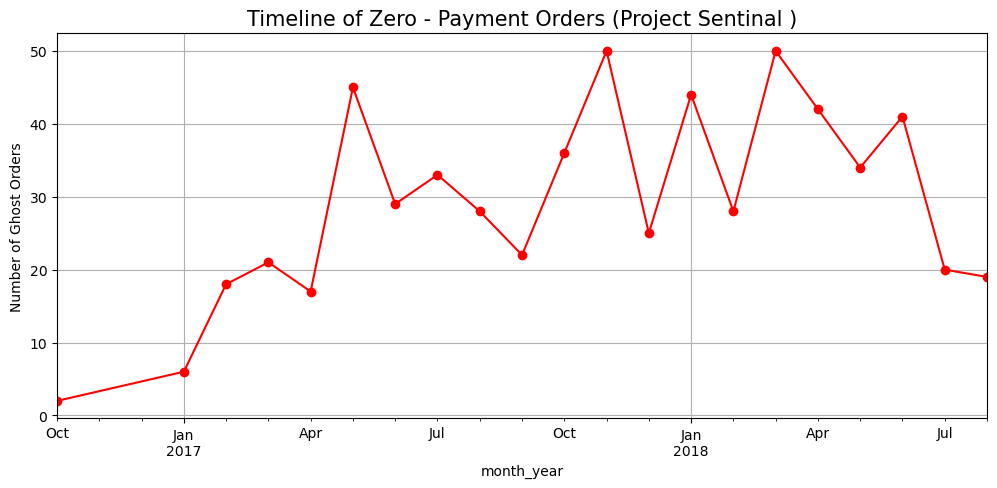

In [181]:
# all this ghost army attack happened only once or is it an everyday leak ? 

#1. Convert timestamp to just month/year 
ghost_orders['month_year'] = ghost_orders['order_purchase_timestamp'].dt.to_period('M')

#2. Group by month to see the trend 
timeline = ghost_orders.groupby('month_year').size()

print ("-- THE GHOST TIMELINE ---")
print (timeline)

#3. Plot it to see if its getting worse 

timeline.plot(kind='line',marker='o',figsize=(12,5), color='red')
plt.title('Timeline of Zero - Payment Orders (Project Sentinal )',fontsize=15)
plt.ylabel('Number of Ghost Orders')
plt.grid(True)
plt.show()

In [159]:
# THE GHOST SENTIMENT AUDIT 

#1. look at the Review Scores for the Ghost Orders 
ghost_reviews = ghost_orders['review_score'].value_counts(normalize=True).sort_index()*100

print ("-- GHOST ORDER SATISFACTION (Percentage) ---")
print (ghost_reviews)

#2. Compare 'Silence' vs 'Active' revierwers in the Ghost Group 
ghost_silence = ghost_orders['is_customer_silent'].value_counts(normalize=True)

print ("\n-- GHOST SILENCE RATE ---")
print (ghost_silence)

-- GHOST ORDER SATISFACTION (Percentage) ---
review_score
1.0    11.551155
2.0     2.805281
3.0     7.425743
4.0    19.306931
5.0    58.910891
Name: proportion, dtype: float64

-- GHOST SILENCE RATE ---
is_customer_silent
1.0    0.60066
0.0    0.39934
Name: proportion, dtype: float64


### 7. DATA VISUALIZATIONS 

In [162]:
import seaborn as sns 

C:\Users\Rajashri\AppData\Local\Temp\ipykernel_19420\2960102904.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.values, y=top_cats.index, ax=axes[0,1], palette='Reds_r')


Project Sentinel: Final Dashboard Generated Successfully.


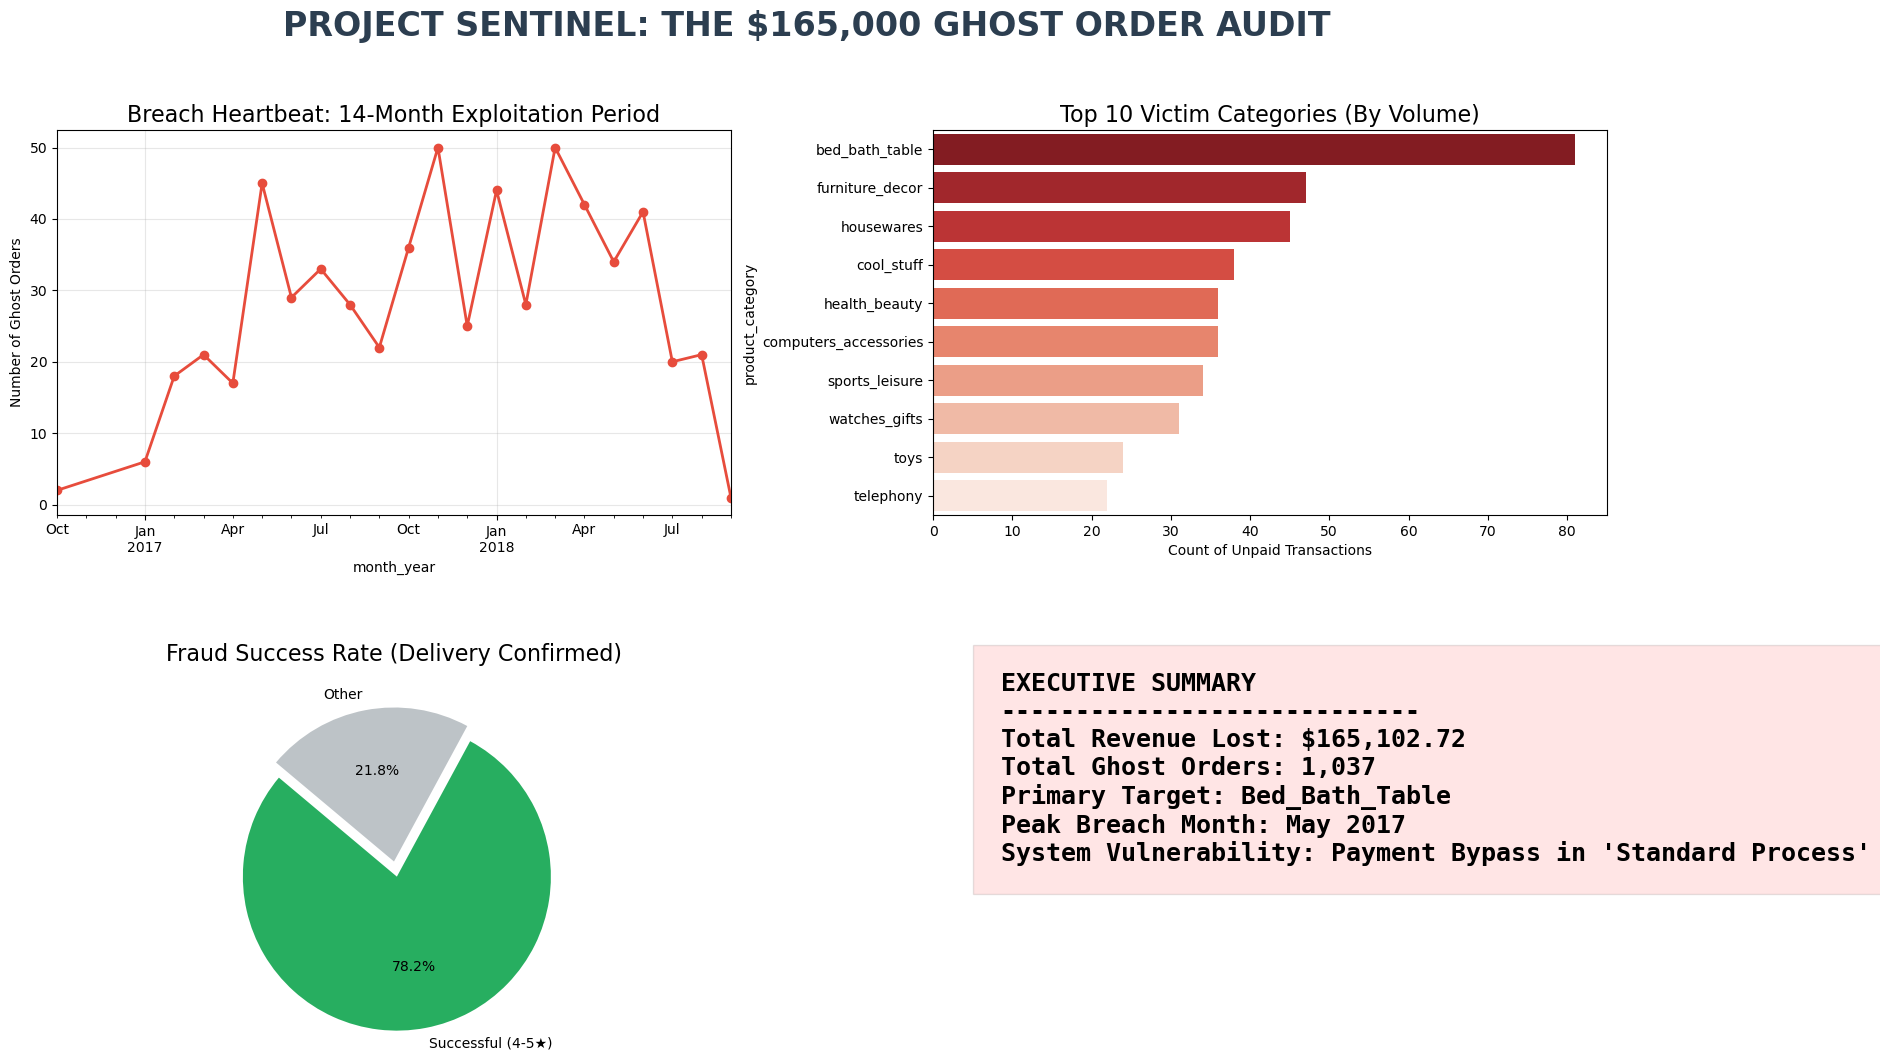

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the dashboard canvas (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)
fig.suptitle('PROJECT SENTINEL: THE $165,000 GHOST ORDER AUDIT', fontsize=24, fontweight='bold', color='#2c3e50')

# 1. Timeline of the Breach (Top Left)
timeline.plot(kind='line', marker='o', ax=axes[0,0], color='#e74c3c', linewidth=2)
axes[0,0].set_title('Breach Heartbeat: 14-Month Exploitation Period', fontsize=16)
axes[0,0].set_ylabel('Number of Ghost Orders')
axes[0,0].grid(True, alpha=0.3)

# 2. Top Victim Categories (Top Right)
top_cats = ghost_orders['product_category'].value_counts().head(10)
sns.barplot(x=top_cats.values, y=top_cats.index, ax=axes[0,1], palette='Reds_r')
axes[0,1].set_title('Top 10 Victim Categories (By Volume)', fontsize=16)
axes[0,1].set_xlabel('Count of Unpaid Transactions')

# 3. Successful Fraud Rate (Bottom Left)
# Combining 4 and 5 star reviews as 'Successful Delivery'

ghost_score_clean = ghost_orders['review_score'].dropna()

success_rate = ghost_score_clean.apply(
    lambda x: 'Successful (4-5★)' if x >= 4 else 'Other'
).value_counts()

labels = success_rate.index.tolist()
values = success_rate.values.tolist()

axes[1,0].pie(values, labels=labels, autopct='%1.1f%%', 
              startangle=140, colors=['#27ae60', '#bdc3c7'], explode=(0.1, 0))
axes[1,0].set_title('Fraud Success Rate (Delivery Confirmed)', fontsize=16)

# 4. Financial Damage Summary (Bottom Right - Text Box)
axes[1,1].axis('off')
summary_text = (
    f"EXECUTIVE SUMMARY\n"
    f"----------------------------\n"
    f"Total Revenue Lost: $165,102.72\n"
    f"Total Ghost Orders: 1,037\n"
    f"Primary Target: Bed_Bath_Table\n"
    f"Peak Breach Month: May 2017\n"
    f"System Vulnerability: Payment Bypass in 'Standard Process'"
)
axes[1,1].text(0.1, 0.5, summary_text, fontsize=18, fontweight='bold', family='monospace', 
               bbox={'facecolor':'red', 'alpha':0.1, 'pad':20})

plt.savefig('Sentinel_Final_Dashboard.png')
print("Project Sentinel: Final Dashboard Generated Successfully.")

# END OF DATA ANALYSIS USING PYTHON [ EXPLORATORY DATA ANALYSIS SUCCESS]

In [169]:
#Export the full cleaned master data 
master_df.to_csv('Sentinel_Master_Data.csv', index=False)

#Export just the fraud case for a specific fraud report page 
ghost_orders.to_csv('Sentinel_Ghost_Orders.csv', index=False)

print ('Files exported ! You are ready to import these files into PowerBI.')

Files exported ! You are ready to import these files into PowerBI.


In [172]:
import pandas as pd 

df_shreya = pd.read_csv('Sentinel_Ghost_Orders.csv')
df_shreya.dtypes

order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
process_gap                       object
payment_sequential               float64
payment_type                      object
payment_installments             float64
payment_value                    float64
order_item_id                    float64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
product_name_lenght              float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_c

In [174]:
df_shreya2 = pd.read_csv('Sentinel_Master_Data.csv')
df_shreya2.shape

(119143, 36)